# LQR → QUBO → QAOA → IBM: Validation and Hardware-Scale Demonstration

**Workflow preserved:** networked LQR cyber-defense control → exact QUBO reduction → QAOA → IBM hardware.

This notebook is organized into two panels with a single, consistent metric.

**PANEL 1 — Validation** (small simulable instance, all methods on the *same full QUBO*):
Greedy · CP-SAT · Local QAOA · IBM QAOA.

**PANEL 2 — Scalability / hardware demonstration** (same QUBO per size):
CP-SAT · IBM QAOA, at q = 64, 128, 152.

**Primary metric — Gap-to-CP-SAT (%):** `Gap = 100 · (E_method − E_cpsat) / |E_cpsat|`.
CP-SAT is the classical reference (Gap ≡ 0). No exact-optimum / approximation-ratio / closed-loop-cost
metrics are reported. Raw energy is never compared across different problem sizes.

**Corrections applied (see Cell 5):** the QUBO→Ising field shift was off by a factor of two
(`h[i] += -0.5*J` → corrected to `h[i] += -J`); QAOA angles are variationally optimized
(COBYLA) and reused for IBM execution; bitstring decoding/endianness verified.

**Scope statement (claim discipline):** *IBM QAOA produces solutions comparable to the classical
reference on validation instances and demonstrates feasibility on larger hardware-scale instances.*
No quantum-advantage claim is made.

In [14]:
# CELL 1 - Dependencies
!pip install numpy pandas matplotlib scipy networkx ortools qiskit qiskit-aer qiskit-ibm-runtime -q
import os, time, itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from ortools.sat.python import cp_model
print("imports ok")

imports ok


In [ ]:
# CELL 2 - Configuration
SEED   = 42
SHOTS  = 2048
QAOA_P = 1                       # QAOA layers (kept = 1 so validation angles transfer to scale)

# Variational optimizer (Local QAOA)
OPT_METHOD, OPT_MAXITER, OPT_SHOTS = "COBYLA", 60, 512

# PANEL 1 - validation instance (small enough to simulate Local QAOA on the FULL QUBO)
VALID_N, VALID_H = 4, 4           # qubits = 16

# PANEL 2 - scalability instances
# PANEL 2 - scalability instances
SCALE_INSTANCES = [
    (8, 8),    # q = 64
    (16, 8),   # q = 128
    (19, 8)    # q = 152
]
MAX_QAOA_EDGES  = {64: 300, 128: 500, 152: 700}   # circuit coupling budget at scale (hardware depth)

# IBM hardware
USE_IBM            = True
RUN_IBM_VALIDATION = True
RUN_IBM_64, RUN_IBM_128, RUN_IBM_152 = True, True, True
IBM_API_KEY  = os.getenv("IBM_QUANTUM_TOKEN")
IBM_CRN = os.getenv("IBM_QUANTUM_INSTANCE")
IBM_BACKEND = "ibm_kingston"

print("validation qubits =", VALID_N*VALID_H, "| scale qubits =", [n*h for n,h in SCALE_INSTANCES])

validation qubits = 16 | scale qubits = [64, 128, 152]


In [16]:
# CELL 3 - Networked LQR model + exact Control->QUBO reduction
def make_network(n, seed=42):
    G = nx.barabasi_albert_graph(n, max(1, min(3, n-1)), seed=seed)
    W = nx.to_numpy_array(G); rs = W.sum(1, keepdims=True); rs[rs == 0] = 1
    return W / rs

def build_system(n, W, delta_s=.10, beta_self=.35, beta_net=.45, rho_v=.35,
                 gamma_theta=.30, theta_spread=.25, eta_theta=.85, eta_v=.65,
                 alpha=.50, vuln_decay=.05):
    A = np.zeros((4*n, 4*n)); B = np.zeros((4*n, n)); F = np.zeros((4*n, n))
    s, th, v, c = slice(0,n), slice(n,2*n), slice(2*n,3*n), slice(3*n,4*n)
    A[s,s]=(1-delta_s)*np.eye(n); A[s,th]=beta_self*np.eye(n)+beta_net*W; A[s,v]=rho_v*np.eye(n)
    A[th,th]=(1-gamma_theta)*np.eye(n)+theta_spread*W; A[v,v]=(1-vuln_decay)*np.eye(n); A[c,c]=np.eye(n)
    B[th,:]=-eta_theta*np.eye(n); B[v,:]=-eta_v*np.eye(n)
    F[th,:]=alpha*np.eye(n); F[v,:]=.20*np.eye(n)
    return A, B, F

def weights(n): return np.diag([4.]*n+[3.]*n+[2.]*n+[1.5]*n), np.diag([.08]*n)
def init_state(n, seed=42):
    r=np.random.default_rng(seed)
    return np.concatenate([np.zeros(n), .15+.10*r.random(n), .20+.50*r.random(n), .30+.70*r.random(n)])
def attack(n, H, seed=42):
    r=np.random.default_rng(seed); w=r.uniform(0,.6,(n,H)); w[:,3:min(6,H)]=.9; return w

def build_qubo(A,B,F,Q,R,x0,w,H):
    sd=A.shape[0]; n=B.shape[1]; m=n*H
    d=x0.copy(); M=np.zeros((sd,m)); Hq=np.zeros((m,m)); gq=np.zeros(m)
    for k in range(H):
        Hq+=M.T@Q@M; gq+=2*M.T@Q@d
        sl=slice(k*n,(k+1)*n); Hq[sl,sl]+=R
        Um=np.zeros((n,m)); Um[:,sl]=np.eye(n)
        d=A@d+F@w[:,k]; M=A@M+B@Um
    Hq+=M.T@Q@M; gq+=2*M.T@Q@d; return .5*(Hq+Hq.T), gq

def make_instance(n, H, seed=SEED):
    W=make_network(n,seed=seed); A,B,F=build_system(n,W); Q,R=weights(n)
    x0=init_state(n,seed); w=attack(n,H,seed)
    Hq,gq=build_qubo(A,B,F,Q,R,x0,w,H)
    return {"n":n,"H":H,"m":n*H,"Hq":Hq,"gq":gq}

def energy(U, Hq, gq): U=np.asarray(U); return float(U@Hq@U + gq@U)
print("model + QUBO reduction ready")

model + QUBO reduction ready


In [17]:
# CELL 4 - Classical methods: Greedy + CP-SAT (reference)
def solve_greedy(Hq, gq):
    m=len(gq); U=np.zeros(m,int)
    for i in range(m):
        if Hq[i,i]+gq[i] < 0: U[i]=1
    return U

def solve_cpsat(Hq, gq, time_limit=20, num_workers=2):
    m=len(gq); model=cp_model.CpModel(); x=[model.NewBoolVar(f"x{i}") for i in range(m)]
    sc=100000; terms=[int(round(sc*(Hq[i,i]+gq[i])))*x[i] for i in range(m)]
    for i in range(m):
        for j in range(i+1,m):
            c=2*Hq[i,j]
            if abs(c)>1e-12:
                y=model.NewBoolVar(f"y{i}_{j}")
                model.Add(y<=x[i]); model.Add(y<=x[j]); model.Add(y>=x[i]+x[j]-1)
                terms.append(int(round(sc*c))*y)
    model.Minimize(sum(terms)); s=cp_model.CpSolver()
    s.parameters.max_time_in_seconds=time_limit; s.parameters.num_search_workers=num_workers
    st=s.Solve(model)
    return np.array([s.Value(x[i]) for i in range(m)],int), (st==cp_model.OPTIMAL)
print("greedy + cp-sat ready")

greedy + cp-sat ready


In [18]:
# CELL 5 - QUBO -> Ising (CORRECTED) + QAOA circuit + decoding  [self-verified]
def qubo_to_ising(Hq, gq, threshold=1e-8, max_edges=None):
    """E(U)=U^T Hq U + gq^T U, U in {0,1}, U_i=(1-z_i)/2.
       Coupling  J_ij = (2*Hq_ij)/4.
       Field shift per coupling = -J_ij  (was -0.5*J_ij : factor-of-2 bug, now FIXED)."""
    m=len(gq); a=np.diag(Hq)+gq; h=-0.5*a.copy(); raw=[]
    for i in range(m):
        for j in range(i+1,m):
            b=2*Hq[i,j]
            if abs(b)>threshold:
                J=0.25*b; raw.append((i,j,J,abs(J)))
    tot=sum(r[3] for r in raw)+1e-12
    raw.sort(key=lambda r:r[3], reverse=True)
    if max_edges is not None: raw=raw[:max_edges]
    kept=sum(r[3] for r in raw)
    edges=[]
    for i,j,J,_ in raw:
        h[i]+=-J; h[j]+=-J                       # <-- CORRECTED (was -0.5*J)
        edges.append((i,j,J))
    return h, edges, kept/tot

def ising_constant(Hq, gq, edges):
    a=np.diag(Hq)+gq; const=0.5*a.sum()
    const+=sum(J for _,_,J in edges); return const

def from_bits(s):  # Qiskit little-endian -> U[i] = qubit i
    return np.array([int(c) for c in s[::-1]], int)

def best_from_counts(counts, Hq, gq):
    best=min(counts, key=lambda s: energy(from_bits(s), Hq, gq))
    return from_bits(best), energy(from_bits(best), Hq, gq)

def build_param_qaoa(h, edges, m, p):
    gs=[Parameter(f"g{l}") for l in range(p)]; bs=[Parameter(f"b{l}") for l in range(p)]
    qc=QuantumCircuit(m,m); qc.h(range(m))
    for l in range(p):
        for i in range(m):
            if abs(h[i])>1e-12: qc.rz(2*gs[l]*h[i], i)
        for i,j,J in edges: qc.rzz(2*gs[l]*J, i, j)
        for i in range(m): qc.rx(2*bs[l], i)
    qc.measure(range(m),range(m))
    return qc, gs+bs

# --- self-verification: corrected Ising must reproduce the QUBO energy exactly ---
_chk=make_instance(3,3,seed=SEED); _Hq,_gq=_chk["Hq"],_chk["gq"]
_h,_edges,_=qubo_to_ising(_Hq,_gq); _const=ising_constant(_Hq,_gq,_edges)
_err=0.0
for _b in itertools.product([0,1],repeat=_chk["m"]):
    _U=np.array(_b); _z=1-2*_U
    _e=_const+float(_h@_z)+sum(J*_z[i]*_z[j] for i,j,J in _edges)
    _err=max(_err, abs(_e-energy(_U,_Hq,_gq)))
assert _err<1e-9, f"Ising mapping mismatch: {_err}"
print(f"QUBO<->Ising self-check passed (max err {_err:.2e}); coupling field shift = -J")

QUBO<->Ising self-check passed (max err 5.51e-14); coupling field shift = -J


In [19]:
# CELL 6 - Local QAOA with variational angle optimization (COBYLA)
def optimize_local_qaoa(inst, p=QAOA_P, max_edges=None, opt_shots=OPT_SHOTS,
                        maxiter=OPT_MAXITER, final_shots=SHOTS, seed=SEED, method=OPT_METHOD):
    Hq,gq,m = inst["Hq"], inst["gq"], inst["m"]
    h,edges,kept = qubo_to_ising(Hq,gq,max_edges=max_edges)
    qc,params = build_param_qaoa(h,edges,m,p)
    sim=AerSimulator(seed_simulator=seed); tqc=transpile(qc,sim,optimization_level=1)
    def expectation(theta):
        cnts=sim.run(tqc.assign_parameters(dict(zip(params,theta))),shots=opt_shots).result().get_counts()
        tot=sum(cnts.values()); return sum(c*energy(from_bits(s),Hq,gq) for s,c in cnts.items())/tot
    rng=np.random.default_rng(seed)
    theta0=np.concatenate([rng.uniform(0.2,1.0,p), rng.uniform(0.2,0.8,p)])
    hist=[]
    t0=time.time()
    out=minimize(lambda th:(lambda v:(hist.append(v),v)[1])(expectation(th)),
                 theta0, method=method, options={"maxiter":maxiter})
    cnts=sim.run(tqc.assign_parameters(dict(zip(params,out.x))),shots=final_shots).result().get_counts()
    U,E=best_from_counts(cnts,Hq,gq)
    return {"angles":out.x, "U":U, "energy":E, "hist":hist,
            "kept":kept, "depth":tqc.depth(), "runtime":time.time()-t0}
print("local QAOA optimizer ready")

local QAOA optimizer ready


In [20]:
# CELL 7 - IBM QAOA runner (auto-select least busy real backend)

def run_ibm_qaoa(inst, angles, p=QAOA_P, max_edges=None, shots=SHOTS):
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit import transpile
    import time

    Hq, gq, m = inst["Hq"], inst["gq"], inst["m"]

    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=IBM_API_KEY,
        instance=IBM_CRN
    )

    # Automatically select the least busy real quantum computer
    backend = service.least_busy(
        operational=True,
        simulator=False
    )

    print(f"Using backend: {backend.name}")

    h, edges, kept = qubo_to_ising(Hq, gq, max_edges=max_edges)

    qc, params = build_param_qaoa(h, edges, m, p)

    bound = qc.assign_parameters(
        dict(zip(params, list(angles)))
    )

    tqc = transpile(
        bound,
        backend=backend,
        optimization_level=1
    )

    sampler = SamplerV2(mode=backend)

    t0 = time.time()

    job = sampler.run([tqc], shots=shots)
    jid = job.job_id()

    print(f"Job submitted: {jid}")

    result = job.result()

    wall = time.time() - t0

    data = result[0].data
    reg = list(data.keys())[0]
    counts = data[reg].get_counts()

    U, E = best_from_counts(counts, Hq, gq)

    return {
        "U": U,
        "energy": E,
        "kept": kept,
        "depth": tqc.depth(),
        "backend": backend.name,
        "job_id": jid,
        "runtime": wall
    }

def gap_to_cpsat(E, E_cpsat):
    return 100.0 * (E - E_cpsat) / abs(E_cpsat)

print("IBM runner ready (auto backend selection)")

IBM runner ready (auto backend selection)


## PANEL 1 — Validation
All four methods solve the **same full QUBO** (no coupling pruning) on the 16-qubit instance.
Local QAOA angles are optimized by COBYLA and **reused** for the IBM run, so Local vs. IBM differ
only by hardware noise. Metric: QUBO energy, Gap-to-CP-SAT (%), runtime.

In [21]:
# CELL 9 - Run Panel 1
p1 = make_instance(VALID_N, VALID_H, seed=SEED)
Hq1, gq1 = p1["Hq"], p1["gq"]
print(f"Validation instance: n={VALID_N}, H={VALID_H}, qubits={p1['m']}")

# CP-SAT reference
t0=time.time(); U_cp, _ = solve_cpsat(Hq1, gq1); rt_cp=time.time()-t0
E_cp = energy(U_cp, Hq1, gq1)

# Greedy
t0=time.time(); U_gr = solve_greedy(Hq1, gq1); rt_gr=time.time()-t0
E_gr = energy(U_gr, Hq1, gq1)

# Local QAOA (FULL QUBO -> max_edges=None) + optimized angles (reused for IBM)
loc = optimize_local_qaoa(p1, max_edges=None)
valid_angles = loc["angles"]
print("Optimized validation angles:", np.round(valid_angles,4))

panel1 = [
    ("Greedy",     E_gr, rt_gr, "classical"),
    ("CP-SAT",     E_cp, rt_cp, "classical reference"),
    ("Local QAOA", loc["energy"], loc["runtime"], "AerSimulator"),
]

# IBM QAOA (same instance, same angles) - gated
if USE_IBM and RUN_IBM_VALIDATION:
    ibm1 = run_ibm_qaoa(p1, valid_angles, max_edges=None)
    panel1.append(("IBM QAOA", ibm1["energy"], ibm1["runtime"], ibm1["backend"]))

panel1_df = pd.DataFrame([{
    "Method": name, "QUBO energy": round(E,4),
    "Gap-to-CP-SAT %": round(gap_to_cpsat(E, E_cp),3),
    "Runtime (s)": round(rt,3), "Backend": bk
} for (name,E,rt,bk) in panel1])
panel1_df.to_csv("panel1_validation.csv", index=False)
panel1_df

Validation instance: n=4, H=4, qubits=16


qiskit_runtime_service._discover_account:WARNING:2026-06-08 23:02:57,126: Loading account with the given token. A saved account will not be used.


Optimized validation angles: [2.6868 1.9084]
Using backend: ibm_marrakesh
Job submitted: d8jjo8jnn5bs738pne90


,Method,QUBO energy,Gap-to-CP-SAT %,Runtime (s),Backend
0,Greedy,152.8038,210.676,0.000,classical
1,CP-SAT,-138.0638,0.000,0.045,classical reference
2,Local QAOA,-136.7491,0.952,0.429,AerSimulator
3,IBM QAOA,-136.0254,1.476,7.308,ibm_marrakesh


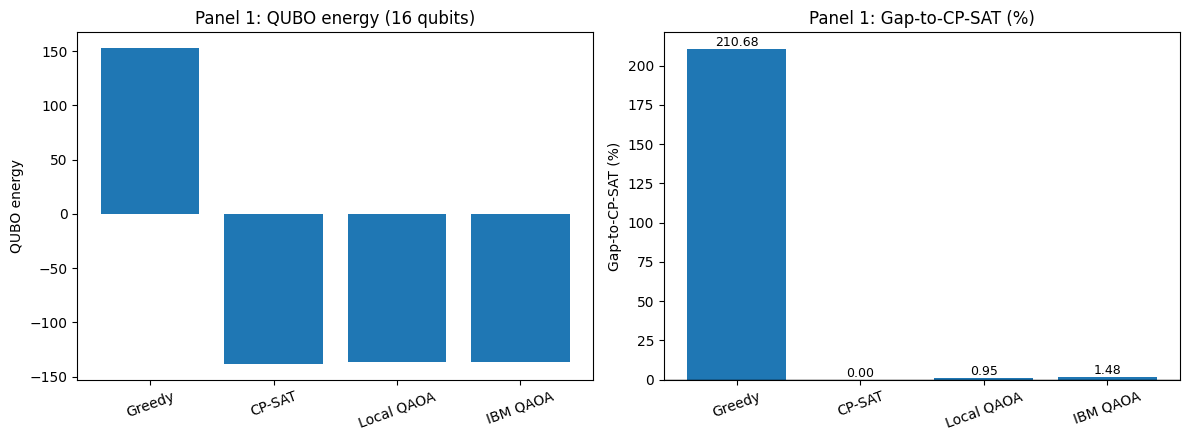

In [22]:
# CELL 10 - Panel 1 grouped comparison figure
fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
names=[r[0] for r in panel1]; Es=[r[1] for r in panel1]; gaps=[gap_to_cpsat(r[1],E_cp) for r in panel1]
ax[0].bar(names, Es); ax[0].set_title(f"Panel 1: QUBO energy ({p1['m']} qubits)")
ax[0].set_ylabel("QUBO energy"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(names, gaps); ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("Panel 1: Gap-to-CP-SAT (%)"); ax[1].set_ylabel("Gap-to-CP-SAT (%)")
ax[1].tick_params(axis="x", rotation=20)
for i,g in enumerate(gaps): ax[1].text(i, g, f"{g:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.savefig("panel1_validation.png", dpi=300); plt.show()

## PANEL 2 — Scalability / Hardware Demonstration
CP-SAT (reference) and IBM QAOA on the **same QUBO** at q = 64, 128, 152. The QAOA circuit retains
the strongest couplings (depth budget); solutions are scored on the identical **full** QUBO CP-SAT
solves. Validation-optimized angles are **transferred** (parameter transferability). Only
Gap-to-CP-SAT (%) is reported — raw energy is never compared across sizes.

In [23]:
# CELL 12 - Run Panel 2
panel2_rows=[]
ibm_flags={64:RUN_IBM_64, 128:RUN_IBM_128, 152:RUN_IBM_152}
for (n,H) in SCALE_INSTANCES:
    inst=make_instance(n,H,seed=SEED); m=inst["m"]; Hq,gq=inst["Hq"],inst["gq"]
    print(f"--- q={m} (n={n},H={H}) ---  CP-SAT ...", end="", flush=True)
    t0=time.time(); U_cp,_=solve_cpsat(Hq,gq,time_limit=20); rt=time.time()-t0; E_cp=energy(U_cp,Hq,gq)
    print(f" {rt:.1f}s, E={E_cp:.2f}")
    panel2_rows.append({"qubits":m, "Method":"CP-SAT (reference)", "QUBO energy":round(E_cp,4),
                        "Gap-to-CP-SAT %":0.0, "Retained couplings %":100.0,
                        "Runtime (s)":round(rt,3), "Backend":"classical"})
    if USE_IBM and ibm_flags.get(m, False):
        res=run_ibm_qaoa(inst, valid_angles, max_edges=MAX_QAOA_EDGES.get(m))
        panel2_rows.append({"qubits":m, "Method":"IBM QAOA", "QUBO energy":round(res["energy"],4),
                            "Gap-to-CP-SAT %":round(gap_to_cpsat(res["energy"],E_cp),3),
                            "Retained couplings %":round(100*res["kept"],2),
                            "Runtime (s)":round(res["runtime"],3), "Backend":res["backend"]})

panel2_df=pd.DataFrame(panel2_rows)
panel2_df.to_csv("panel2_scalability.csv", index=False)
panel2_df

--- q=64 (n=8,H=8) ---  CP-SAT ...

qiskit_runtime_service._discover_account:WARNING:2026-06-08 23:03:40,601: Loading account with the given token. A saved account will not be used.


 20.0s, E=-3603.50
Using backend: ibm_marrakesh
Job submitted: d8jjohbnn5bs738pnel0
--- q=128 (n=16,H=8) ---  CP-SAT ...

qiskit_runtime_service._discover_account:WARNING:2026-06-08 23:04:15,950: Loading account with the given token. A saved account will not be used.


 20.1s, E=-6996.55
Using backend: ibm_marrakesh
Job submitted: d8jjoq032u0s73f7kgr0
--- q=152 (n=19,H=8) ---  CP-SAT ...

qiskit_runtime_service._discover_account:WARNING:2026-06-08 23:04:51,333: Loading account with the given token. A saved account will not be used.


 20.2s, E=-8179.53
Using backend: ibm_marrakesh
Job submitted: d8jjp3jqv2lc73845ieg


,qubits,Method,QUBO energy,Gap-to-CP-SAT %,Retained couplings %,Runtime (s),Backend
0,64,CP-SAT (reference),-3603.5012,0.000,100.00,20.045,classical
1,64,IBM QAOA,-3454.6028,4.132,60.09,7.470,ibm_marrakesh
2,128,CP-SAT (reference),-6996.5503,0.000,100.00,20.120,classical
3,128,IBM QAOA,-6501.2573,7.079,43.45,7.827,ibm_marrakesh
4,152,CP-SAT (reference),-8179.5328,0.000,100.00,20.219,classical
5,152,IBM QAOA,-7533.3758,7.900,46.43,32.916,ibm_marrakesh


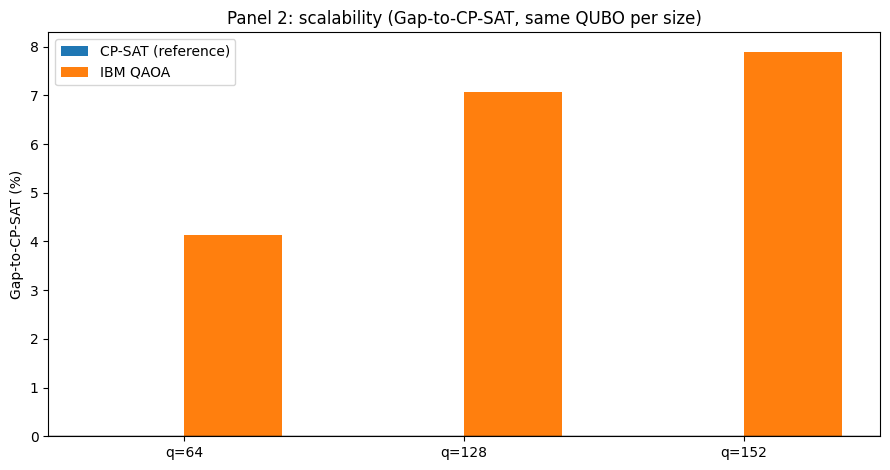

Note: CP-SAT is the reference (gap=0). IBM QAOA bars appear when USE_IBM and RUN_IBM_* are set.


In [24]:
# CELL 13 - Panel 2 grouped comparison figure (Gap-to-CP-SAT % only)
sizes=sorted(panel2_df["qubits"].unique())
methods=["CP-SAT (reference)","IBM QAOA"]; width=0.35; x=np.arange(len(sizes))
plt.figure(figsize=(9,4.8))
for k,mth in enumerate(methods):
    vals=[]
    for s in sizes:
        row=panel2_df[(panel2_df["qubits"]==s)&(panel2_df["Method"]==mth)]
        vals.append(row["Gap-to-CP-SAT %"].iloc[0] if len(row) else np.nan)
    plt.bar(x+(k-0.5)*width, vals, width, label=mth)
plt.axhline(0,color="k",lw=1); plt.xticks(x,[f"q={s}" for s in sizes])
plt.ylabel("Gap-to-CP-SAT (%)"); plt.title("Panel 2: scalability (Gap-to-CP-SAT, same QUBO per size)")
plt.legend(); plt.tight_layout(); plt.savefig("panel2_scalability.png", dpi=300); plt.show()
print("Note: CP-SAT is the reference (gap=0). IBM QAOA bars appear when USE_IBM and RUN_IBM_* are set.")

## Scope & Claims
- **Validation:** on a 16-qubit instance where all four methods solve the identical QUBO, IBM QAOA
  is assessed for *comparability* to the CP-SAT reference via Gap-to-CP-SAT (%).
- **Scalability:** at 64/128/152 qubits, the workflow demonstrates *feasibility* of executing the
  control-derived QUBO on real hardware against the classical reference.
- **No quantum-advantage claim is made.** The supported statement is: *IBM QAOA produces solutions
  comparable to the classical reference on validation instances and demonstrates feasibility on
  larger hardware-scale instances.*

In [25]:
# CELL 15 - LaTeX export
print("% --- Panel 1 (validation) ---")
print(panel1_df.to_latex(index=False))
print("% --- Panel 2 (scalability) ---")
print(panel2_df.to_latex(index=False))

% --- Panel 1 (validation) ---
\begin{tabular}{lrrrl}
\toprule
Method & QUBO energy & Gap-to-CP-SAT % & Runtime (s) & Backend \\
\midrule
Greedy & 152.803800 & 210.676000 & 0.000000 & classical \\
CP-SAT & -138.063800 & 0.000000 & 0.045000 & classical reference \\
Local QAOA & -136.749100 & 0.952000 & 0.429000 & AerSimulator \\
IBM QAOA & -136.025400 & 1.476000 & 7.308000 & ibm_marrakesh \\
\bottomrule
\end{tabular}

% --- Panel 2 (scalability) ---
\begin{tabular}{rlrrrrl}
\toprule
qubits & Method & QUBO energy & Gap-to-CP-SAT % & Retained couplings % & Runtime (s) & Backend \\
\midrule
64 & CP-SAT (reference) & -3603.501200 & 0.000000 & 100.000000 & 20.045000 & classical \\
64 & IBM QAOA & -3454.602800 & 4.132000 & 60.090000 & 7.470000 & ibm_marrakesh \\
128 & CP-SAT (reference) & -6996.550300 & 0.000000 & 100.000000 & 20.120000 & classical \\
128 & IBM QAOA & -6501.257300 & 7.079000 & 43.450000 & 7.827000 & ibm_marrakesh \\
152 & CP-SAT (reference) & -8179.532800 & 0.000000 & 100.000